# Detección de Barcos en Imágenes Satelitales

**Dataset:** Ships in Satellite Imagery (Kaggle · rhammell)  
**Duración:** 6 horas de clase  
**Entorno:** Google Colab (GPU T4 gratuita)  
**Frameworks:** TensorFlow 2.x / Keras, scikit-learn, matplotlib

---

## Estructura del notebook

| Hora | Contenido |
|------|-----------|
| H1   | Configuración del entorno y dataset |
| H2   | Análisis exploratorio y preprocesamiento |
| H3   | Modelo baseline — CNN desde cero |
| H4   | Transfer Learning — MobileNetV2 |
| H5   | Interpretabilidad y análisis de errores |
| H6   | Evaluación final, exportación y cierre |

---
# 1 — Configuración del entorno y dataset
> **Objetivos:** activar GPU, descargar el dataset desde Kaggle, explorar la estructura de los datos y visualizar muestras representativas.

## 1.1 — Verificación del entorno y GPU

In [ ]:
#  Verificar que la GPU está disponible
# En Colab: Runtime → Change runtime type → T4 GPU

import tensorflow as tf
import sys

print(f'Python:      {sys.version.split()[0]}')
print(f'TensorFlow:  {tf.__version__}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU activa:  {gpus[0].name} ')
else:
    print('  No se detectó GPU. Ir a Runtime → Change runtime type → T4 GPU')

## 1.2 — Instalación de dependencias y configuración de Kaggle

In [ ]:
# Instalar la librería de Kaggle
!pip install kaggle --quiet

# ─────────────────────────────────────────────────────────────
# INSTRUCCIONES PARA OBTENER TU API KEY:
#   1. Ir a https://www.kaggle.com → Account → API → Create New Token
#   2. Se descarga kaggle.json con tu usuario y key
#   3. Subir el archivo aquí abajo (Upload kaggle.json)
# ─────────────────────────────────────────────────────────────

from google.colab import files
print(' Subí tu archivo kaggle.json:')
uploaded = files.upload()

 Subí tu archivo kaggle.json:


Saving kaggle.json to kaggle (1).json


In [ ]:
import os

# Configurar credenciales de Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print(' Credenciales de Kaggle configuradas')

 Credenciales de Kaggle configuradas


## 1.3 — Descarga y extracción del dataset

In [ ]:
# Descargar el dataset de Kaggle (~50 MB)
!kaggle datasets download -d rhammell/ships-in-satellite-imagery --quiet
!unzip -q ships-in-satellite-imagery.zip -d data/
print(' Dataset descargado y extraído en /data')

Dataset URL: https://www.kaggle.com/datasets/rhammell/ships-in-satellite-imagery
License(s): CC-BY-SA-4.0
replace data/scenes/scenes/lb_1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename:  Dataset descargado y extraído en /data


In [ ]:
import glob

# Explorar estructura de archivos
print('Estructura del dataset:')
for root, dirs, files_list in os.walk('data/'):
    level = root.replace('data/', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 1:
        subindent = '  ' * (level + 1)
        print(f'{subindent}... ({len(files_list)} archivos)')

Estructura del dataset:
/
scenes/
  scenes/
    ... (8 archivos)
shipsnet/
  shipsnet/
    ... (4000 archivos)


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Cargar el archivo de etiquetas (shipsnet.json)
JSON_PATH = 'data/shipsnet.json'

with open(JSON_PATH) as f:
    dataset = json.load(f)

# Convertir a arrays numpy
X_raw = np.array(dataset['data'], dtype=np.float32)    # (N, 19200) = (N, 3*80*80)
y_raw = np.array(dataset['labels'], dtype=np.int32)    # 1=barco, 0=no barco

# Reformar a imágenes (N, 80, 80, 3)
X_images = X_raw.reshape(-1, 3, 80, 80).transpose(0, 2, 3, 1) / 255.0

print(f'Total de imágenes: {len(X_images)}')
print(f'Shape:             {X_images.shape}')
print(f'Barcos (clase 1):  {y_raw.sum()}')
print(f'No barcos (clase 0): {(y_raw == 0).sum()}')

Total de imágenes: 4000
Shape:             (4000, 80, 80, 3)
Barcos (clase 1):  1000
No barcos (clase 0): 3000


## 1.4 — Visualización de muestras

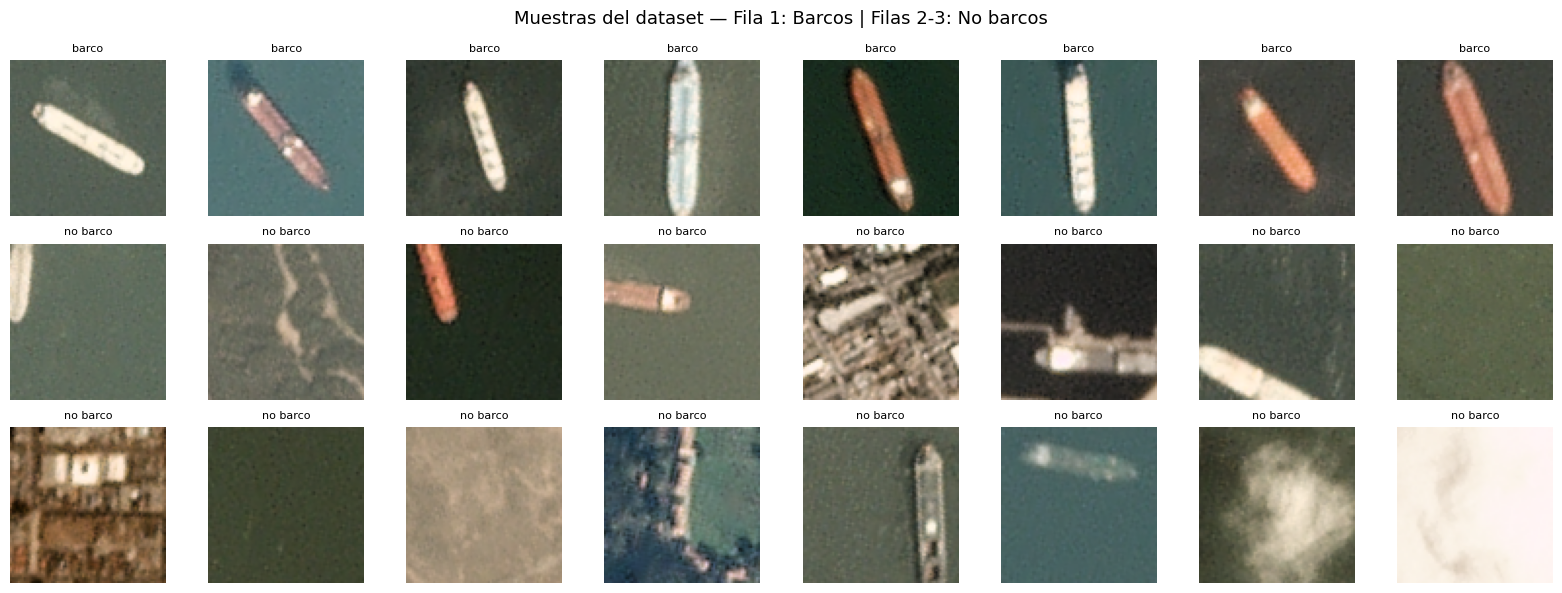

In [ ]:
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle('Muestras del dataset — Fila 1: Barcos | Filas 2-3: No barcos', fontsize=13)

ship_idx    = np.where(y_raw == 1)[0]
noship_idx  = np.where(y_raw == 0)[0]

rng = np.random.default_rng(42)

for i, idx in enumerate(rng.choice(ship_idx, 8, replace=False)):
    axes[0, i].imshow(X_images[idx])
    axes[0, i].set_title('barco', fontsize=8)
    axes[0, i].axis('off')

for row in range(1, 3):
    for i, idx in enumerate(rng.choice(noship_idx, 8, replace=False)):
        axes[row, i].imshow(X_images[idx])
        axes[row, i].set_title('no barco', fontsize=8)
        axes[row, i].axis('off')

plt.tight_layout()
plt.show()

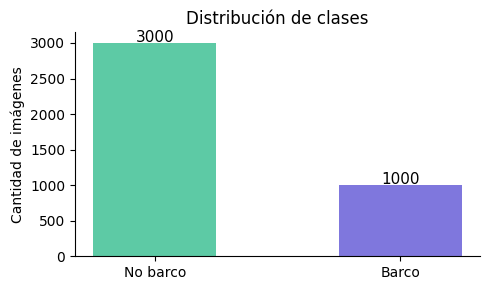

Ratio barco/no-barco: 0.33  (desbalance leve, manejable)


In [ ]:
# Distribución de clases
labels_name = ['No barco', 'Barco']
counts = [(y_raw == i).sum() for i in range(2)]

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
bars = ax.bar(labels_name, counts, color=['#5DCAA5', '#7F77DD'], width=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha='center', fontsize=11)
ax.set_title('Distribución de clases', fontsize=12)
ax.set_ylabel('Cantidad de imágenes')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

ratio = counts[1] / counts[0]
print(f'Ratio barco/no-barco: {ratio:.2f}  (desbalance leve, manejable)')

---
# 2 — Análisis exploratorio y preprocesamiento
> **Objetivos:** analizar distribuciones de pixel por clase, dividir el dataset en train/val/test, construir un pipeline de data augmentation.

## 2.1 — Análisis de distribuciones por canal

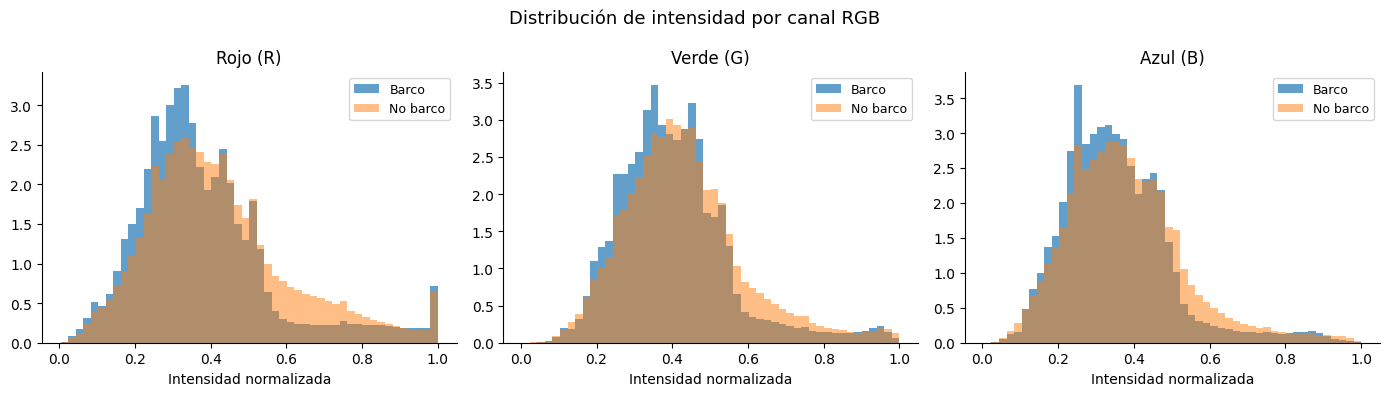

In [ ]:
channel_names = ['Rojo (R)', 'Verde (G)', 'Azul (B)']
colors = ['#E24B4A', '#639922', '#378ADD']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribución de intensidad por canal RGB', fontsize=13)

for ch, (ax, name, color) in enumerate(zip(axes, channel_names, colors)):
    for cls, label, alpha in [(1, 'Barco', 0.7), (0, 'No barco', 0.5)]:
        mask = y_raw == cls
        vals = X_images[mask, :, :, ch].flatten()
        ax.hist(vals, bins=50, alpha=alpha, label=label, density=True)
    ax.set_title(name)
    ax.set_xlabel('Intensidad normalizada')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## 2.2 — División train / validation / test

In [ ]:
from sklearn.model_selection import train_test_split

# División estratificada: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_images, y_raw, test_size=0.30, stratify=y_raw, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f'Train:      {len(X_train)} imágenes  (barcos: {y_train.sum()})')
print(f'Validation: {len(X_val)} imágenes  (barcos: {y_val.sum()})')
print(f'Test:       {len(X_test)} imágenes  (barcos: {y_test.sum()})')

Train:      2800 imágenes  (barcos: 700)
Validation: 600 imágenes  (barcos: 150)
Test:       600 imágenes  (barcos: 150)


## 2.3 — Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Pipeline de augmentation para entrenamiento
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    vertical_flip=True,
)

# Para validación y test: sin augmentation, solo normalización
val_datagen  = ImageDataGenerator()
test_datagen = ImageDataGenerator()

BATCH_SIZE = 32

train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=42)
val_gen   = val_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)
test_gen  = test_datagen.flow(X_test,  y_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Generadores creados — batch size: {BATCH_SIZE}')

Generadores creados — batch size: 32


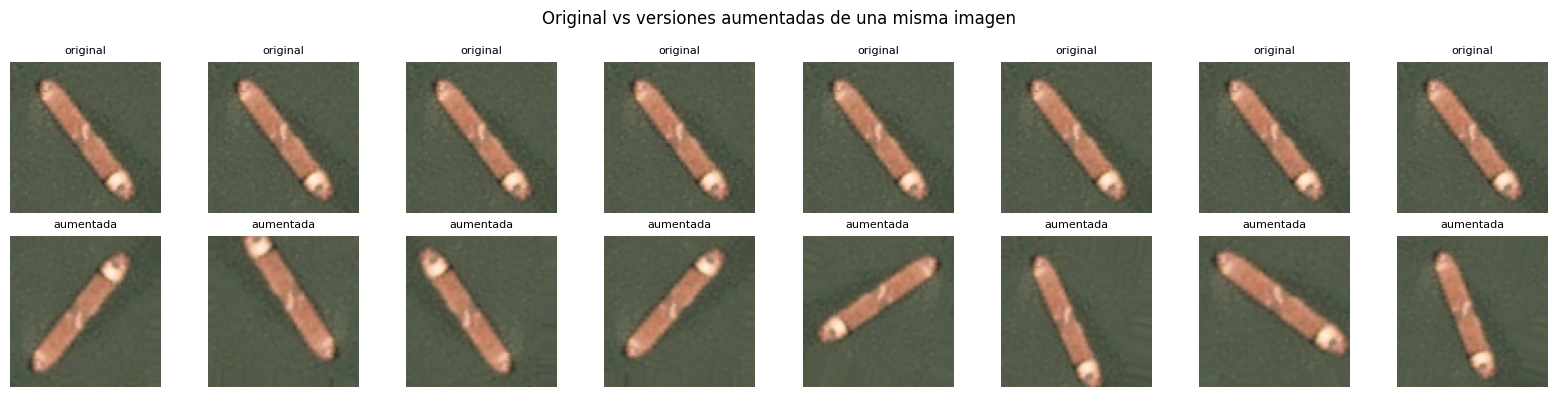

In [ ]:
# Visualizar ejemplos aumentados vs originales
ship_sample = X_train[y_train == 1][:1]  # Un barco
aug_gen = train_datagen.flow(ship_sample, batch_size=1, seed=0)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Original vs versiones aumentadas de una misma imagen', fontsize=12)

for i in range(8):
    axes[0, i].imshow(ship_sample[0])
    axes[0, i].set_title('original', fontsize=8)
    axes[0, i].axis('off')
    aug_img = next(aug_gen)[0]
    axes[1, i].imshow(aug_img)
    axes[1, i].set_title('aumentada', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

---
# 3 — Modelo baseline: CNN desde cero
> **Objetivos:** diseñar y entrenar una CNN sencilla, visualizar las curvas de aprendizaje, establecer una métrica baseline para comparar con transfer learning.

## 3.1 — Arquitectura de la CNN

In [ ]:
from tensorflow.keras import layers, models, optimizers

def build_cnn_baseline(input_shape=(80, 80, 3)):
    model = models.Sequential([
        # ── Bloque 1 ──────────────────────────────────────
        layers.Conv2D(32, (3,3), padding='same', activation='relu',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # ── Bloque 2 ──────────────────────────────────────
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # ── Bloque 3 ──────────────────────────────────────
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # ── Clasificador ──────────────────────────────────
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid'),
    ], name='CNN_Baseline')
    return model

cnn_model = build_cnn_baseline()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 80, 80, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 80, 80, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 40, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 40, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,779,361 (6.79 MB)

 Trainable params: 1,778,721 (6.79 MB)

 Non-trainable params: 640 (2.50 KB)

## 3.2 — Compilación y entrenamiento

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True,
                  verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1,
                      min_lr=1e-6),
    ModelCheckpoint('best_cnn.keras', monitor='val_auc', save_best_only=True,
                    mode='max', verbose=0),
]

print(' Iniciando entrenamiento de CNN baseline...')
history_cnn = cnn_model.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=callbacks_cnn,
    verbose=1
)

 Iniciando entrenamiento de CNN baseline...
Epoch 1/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 42s 222ms/step - accuracy: 0.8425 - auc: 0.8682 - loss: 0.8085 - val_accuracy: 0.2500 - val_auc: 0.5022 - val_loss: 6.0775 - learning_rate: 0.0010
Epoch 2/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - accuracy: 0.8921 - auc: 0.9504 - loss: 0.2520 - val_accuracy: 0.2500 - val_auc: 0.4974 - val_loss: 5.1387 - learning_rate: 0.0010
Epoch 3/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - accuracy: 0.9150 - auc: 0.9632 - loss: 0.2177 - val_accuracy: 0.7050 - val_auc: 0.6013 - val_loss: 1.6590 - learning_rate: 0.0010
Epoch 4/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - accuracy: 0.9211 - auc: 0.9676 - loss: 0.1987 - val_accuracy: 0.7550 - val_auc: 0.9221 - val_loss: 0.5508 - learning_rate: 0.0010
Epoch 5/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.9279 - auc: 0.9688 - loss: 0.2024 - val_accuracy: 0.8667 - val_auc: 0.9171 - val_loss: 0.4669 - learning_rate: 0.0010
Epoch 6/25
88/88 ━━━━━━━━━━━━━━

## 3.3 — Curvas de aprendizaje

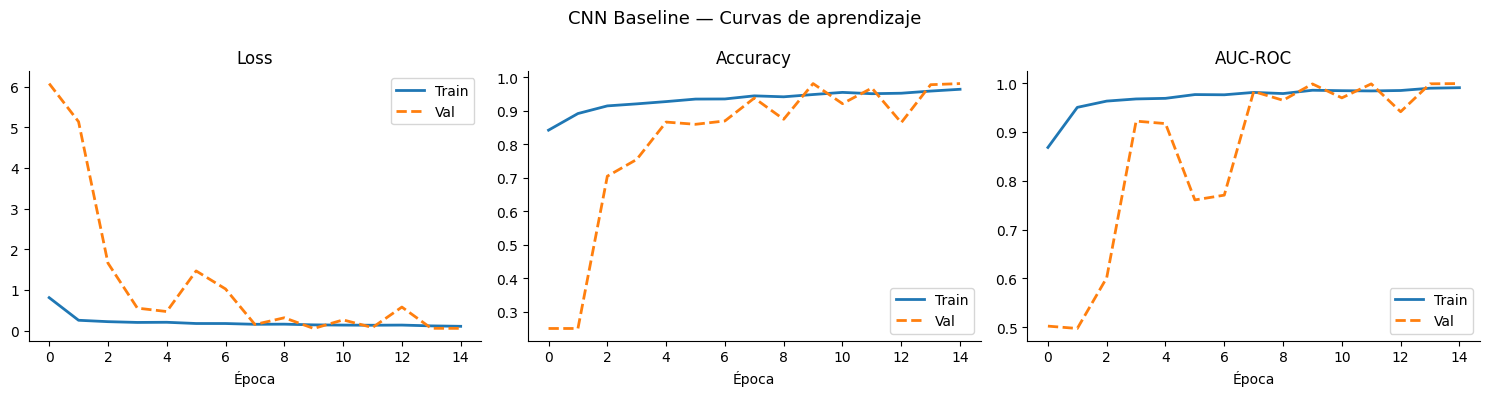

In [ ]:
def plot_history(history, title='Curvas de aprendizaje'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title, fontsize=13)

    metrics = [('loss', 'Loss'), ('accuracy', 'Accuracy'), ('auc', 'AUC-ROC')]
    for ax, (metric, label) in zip(axes, metrics):
        ax.plot(history.history[metric],       label='Train', linewidth=2)
        ax.plot(history.history[f'val_{metric}'], label='Val',   linewidth=2, linestyle='--')
        ax.set_title(label)
        ax.set_xlabel('Época')
        ax.legend()
        ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_history(history_cnn, 'CNN Baseline — Curvas de aprendizaje')

## 3.4 — Evaluación baseline sobre el test set


  CNN Baseline — Evaluación en Test Set
              precision    recall  f1-score   support

    No barco       0.98      0.98      0.98       450
       Barco       0.94      0.95      0.95       150

    accuracy                           0.97       600
   macro avg       0.96      0.97      0.96       600
weighted avg       0.97      0.97      0.97       600

AUC-ROC: 0.9956


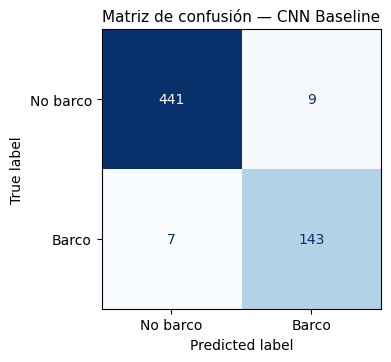

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
)

def evaluate_model(model, X_test, y_test, model_name='Modelo'):
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    print(f'\n{'='*50}')
    print(f'  {model_name} — Evaluación en Test Set')
    print(f'{'='*50}')
    print(classification_report(y_test, y_pred,
                                 target_names=['No barco', 'Barco']))
    print(f'AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}')

    fig, ax = plt.subplots(figsize=(4, 4))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No barco', 'Barco'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de confusión — {model_name}', fontsize=11)
    plt.tight_layout()
    plt.show()

    return y_prob, y_pred

y_prob_cnn, y_pred_cnn = evaluate_model(cnn_model, X_test, y_test, 'CNN Baseline')

---
# 4 — Transfer Learning con MobileNetV2
> **Objetivos:** cargar MobileNetV2 preentrenado en ImageNet, agregar una cabeza de clasificación personalizada, comparar resultados con el baseline.

## 4.1 — Construcción del modelo con MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model, Input

def build_mobilenet_model(input_shape=(80, 80, 3), trainable_base=False):
    # Cargar base preentrenada sin la capa de clasificación
    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base.trainable = trainable_base  # Congelar en la primera fase

    # Construir modelo con cabeza personalizada
    inputs = Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='MobileNetV2_Classifier')
    return model, base

mobilenet_model, base_model = build_mobilenet_model(trainable_base=False)

print(f'Parámetros totales:    {mobilenet_model.count_params():,}')
print(f'Parámetros entrenables: {sum(w.numpy().size for w in mobilenet_model.trainable_weights):,}')
print(f'Base congelada:        {not base_model.trainable}')

/tmp/ipykernel_3200/901717321.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


Parámetros totales:    2,340,033
Parámetros entrenables: 82,049
Base congelada:        True


## 4.2 — Fase 1: Entrenar solo la cabeza

In [ ]:
mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_mn = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint('best_mobilenet.keras', monitor='val_auc', save_best_only=True,
                    mode='max', verbose=0),
]

print('🚀 Fase 1: Entrenando solo la cabeza de clasificación...')
history_mn1 = mobilenet_model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=callbacks_mn,
    verbose=1
)

🚀 Fase 1: Entrenando solo la cabeza de clasificación...
Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 62s 511ms/step - accuracy: 0.9111 - auc: 0.9511 - loss: 0.2349 - val_accuracy: 0.9767 - val_auc: 0.9958 - val_loss: 0.0800 - learning_rate: 0.0010
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - accuracy: 0.9618 - auc: 0.9874 - loss: 0.1170 - val_accuracy: 0.9833 - val_auc: 0.9979 - val_loss: 0.0578 - learning_rate: 0.0010
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step - accuracy: 0.9668 - auc: 0.9922 - loss: 0.0947 - val_accuracy: 0.9750 - val_auc: 0.9987 - val_loss: 0.0583 - learning_rate: 0.0010
Epoch 4/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 144ms/step - accuracy: 0.9718 - auc: 0.9948 - loss: 0.0781 - val_accuracy: 0.9867 - val_auc: 0.9989 - val_loss: 0.0420 - learning_rate: 0.0010
Epoch 5/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.9732 - auc: 0.9940 - loss: 0.0796 - val_accuracy: 0.9900 - val_auc: 0.9995 - val_loss: 0.0326 - learning_rate: 0.0010
Epoch 6/15
88/88 ━━━

## 4.3 — Fase 2: Fine-tuning (descongelar capas superiores)

In [ ]:
# Descongelar las últimas 30 capas de la base
base_model.trainable = True
FINETUNE_AT = len(base_model.layers) - 30

for layer in base_model.layers[:FINETUNE_AT]:
    layer.trainable = False

n_trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Capas descongeladas: {n_trainable} de {len(base_model.layers)}')

# Recompilar con learning rate muy pequeño
mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print('\n Fase 2: Fine-tuning con learning rate reducido...')
history_mn2 = mobilenet_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks_mn,
    verbose=1
)

Capas descongeladas: 30 de 154

 Fase 2: Fine-tuning con learning rate reducido...
Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 71s 527ms/step - accuracy: 0.9346 - auc: 0.9694 - loss: 0.1857 - val_accuracy: 0.9633 - val_auc: 0.9965 - val_loss: 0.1005 - learning_rate: 1.0000e-05
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9530 - auc: 0.9851 - loss: 0.1247
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
88/88 ━━━━━━━━━━━━━━━━━━━━ 40s 136ms/step - accuracy: 0.9571 - auc: 0.9887 - loss: 0.1125 - val_accuracy: 0.9500 - val_auc: 0.9958 - val_loss: 0.1374 - learning_rate: 1.0000e-05
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - accuracy: 0.9679 - auc: 0.9938 - loss: 0.0849 - val_accuracy: 0.9517 - val_auc: 0.9971 - val_loss: 0.1296 - learning_rate: 5.0000e-06
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9631 - auc: 0.9898 - loss: 0.1011
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
88/88 ━━━

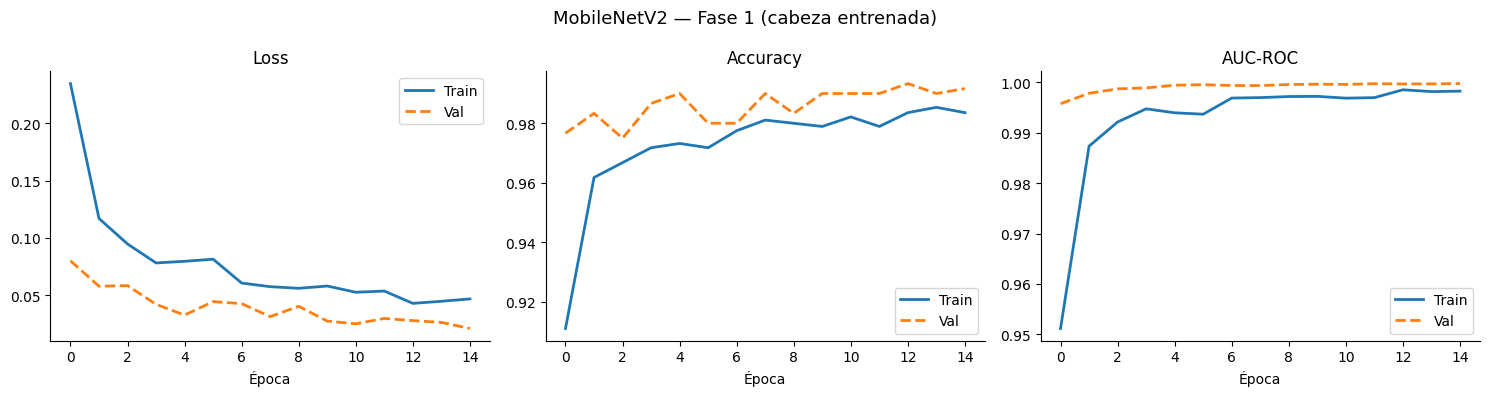

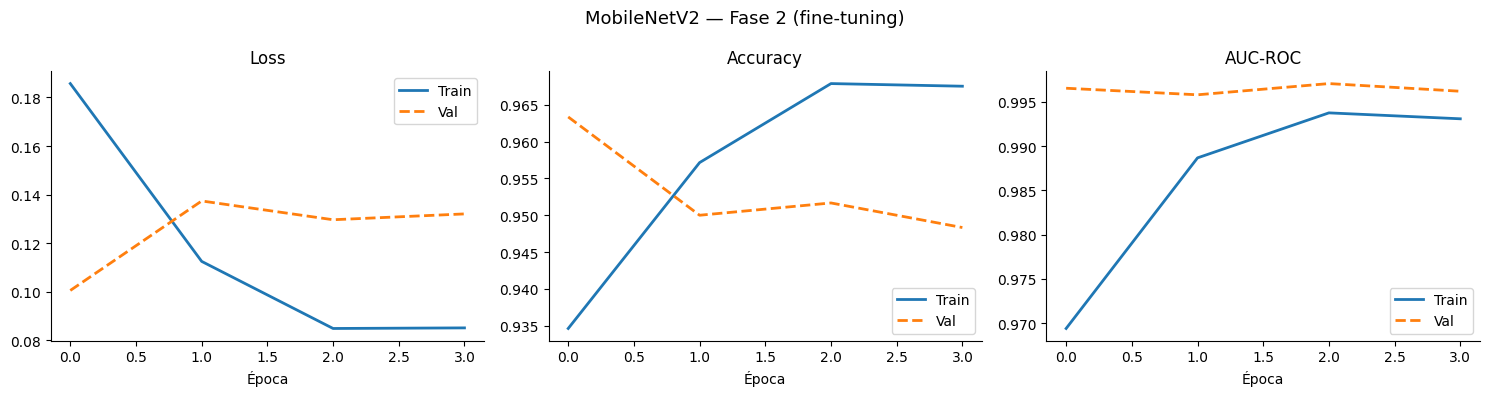

In [ ]:
plot_history(history_mn1, 'MobileNetV2 — Fase 1 (cabeza entrenada)')
plot_history(history_mn2, 'MobileNetV2 — Fase 2 (fine-tuning)')

## 4.4 — Evaluación y comparación de modelos


  MobileNetV2 — Evaluación en Test Set
              precision    recall  f1-score   support

    No barco       0.99      0.95      0.97       450
       Barco       0.86      0.97      0.92       150

    accuracy                           0.95       600
   macro avg       0.93      0.96      0.94       600
weighted avg       0.96      0.95      0.96       600

AUC-ROC: 0.9954


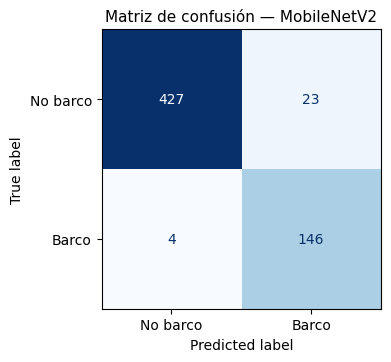

In [ ]:
y_prob_mn, y_pred_mn = evaluate_model(
    mobilenet_model, X_test, y_test, 'MobileNetV2'
)

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score # Import roc_auc_score

# Tabla comparativa
print('\n' + '='*55)
print('  Comparación: CNN Baseline vs MobileNetV2')
print('='*55)
print(f'{"Métrica":<25} {"CNN Baseline":>12} {"MobileNetV2":>12}')
print('-'*55)

metrics_compare = [
    ('Accuracy',  lambda y,p: (y==p).mean(),                      y_pred_cnn, y_pred_mn),
    ('Precision', lambda y,p: precision_score(y,p, zero_division=0),               y_pred_cnn, y_pred_mn),
    ('Recall',    lambda y,p: recall_score(y,p, zero_division=0),                  y_pred_cnn, y_pred_mn),
    ('F1-Score',  lambda y,p: f1_score(y,p, zero_division=0),                      y_pred_cnn, y_pred_mn),
    ('AUC-ROC',   lambda y,p: roc_auc_score(y_test,
                              y_prob_cnn if p is y_pred_cnn else y_prob_mn), y_pred_cnn, y_pred_mn),
]

for name, fn, pred_cnn, pred_mn in metrics_compare:
    val_cnn = fn(y_test, pred_cnn)
    val_mn  = fn(y_test, pred_mn)
    winner  = '🏆' if val_mn > val_cnn else '  '
    print(f'{name:<25} {val_cnn:>12.4f} {val_mn:>11.4f} {winner}')

print('='*55)
print(f'{"Parámetros":<25} {cnn_model.count_params():>12,} {mobilenet_model.count_params():>12,}')


  Comparación: CNN Baseline vs MobileNetV2
Métrica                   CNN Baseline  MobileNetV2
-------------------------------------------------------
Accuracy                        0.9733      0.9550   
Precision                       0.9408      0.8639   
Recall                          0.9533      0.9733 🏆
F1-Score                        0.9470      0.9154   
AUC-ROC                         0.9956      0.9954   
Parámetros                   1,779,361    2,340,033


---
# 5 — Interpretabilidad y análisis de errores
> **Objetivos:** implementar Grad-CAM para visualizar qué regiones activan la detección, analizar falsos positivos/negativos, explorar el umbral de decisión.

## 5.1 — Implementación de Grad-CAM

In [ ]:
import tensorflow as tf
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Genera un mapa de calor Grad-CAM para una imagen.
    img_array: (1, H, W, C) normalizado entre 0 y 1
    """
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array, training=False)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img, heatmap, alpha=0.4):
    """Superpone el mapa de calor sobre la imagen original."""
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    img_uint8 = np.uint8(255 * img)
    superimposed = cv2.addWeighted(img_uint8, 1 - alpha,
                                    heatmap_colored, alpha, 0)
    return superimposed

print(' Funciones Grad-CAM definidas')

 Funciones Grad-CAM definidas


TESTEO EL ERROR

In [ ]:
print("Input del mobilenet_model:", mobilenet_model.inputs)
print("Nombre del base_model:", base_model.name)
print("\nCapas del mobilenet_model:")
for layer in mobilenet_model.layers:
    print(f"  {layer.name} — {type(layer).__name__}")

Input del mobilenet_model: [<KerasTensor shape=(None, 80, 80, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_368>]
Nombre del base_model: mobilenetv2_1.00_224

Capas del mobilenet_model:
  input_layer_5 — InputLayer
  mobilenetv2_1.00_224 — Functional
  global_average_pooling2d_1 — GlobalAveragePooling2D
  dense_6 — Dense
  dropout_9 — Dropout
  dense_7 — Dense


El problema era que mobilenetv2_1.00_224 es un modelo Functional anidado — y Conv_1 está dentro de él, pero su grafo de tensores es independiente del input de mobilenet_model. Por eso el KeyError.
La solución es construir gradcam_model usando call funcional explícito:


In [ ]:
# CELDA 1 - Enfoque completamente diferente: backend funcional directo
mobilenet_base = mobilenet_model.get_layer('mobilenetv2_1.00_224')

# Obtener tensores simbólicos directamente del grafo del base_model
base_input = mobilenet_base.input       # input simbólico del base_model
base_conv  = mobilenet_base.get_layer('out_relu').output  # output simbólico de out_relu

# Modelo que va desde el input del base_model hasta out_relu
conv_model = tf.keras.models.Model(inputs=base_input, outputs=base_conv)

print('conv_model listo:', conv_model.output_shape)
print('mobilenet_model input:', mobilenet_model.input_shape)

conv_model listo: (None, 3, 3, 1280)
mobilenet_model input: (None, 80, 80, 3)


In [ ]:
mobilenet_base = mobilenet_model.get_layer('mobilenetv2_1.00_224')
print("Últimas 5 capas dentro de MobileNetV2:")
for layer in mobilenet_base.layers[-5:]:
    print(f"  {layer.name} — {type(layer).__name__}")

Últimas 5 capas dentro de MobileNetV2:
  block_16_project — Conv2D
  block_16_project_BN — BatchNormalization
  Conv_1 — Conv2D
  Conv_1_bn — BatchNormalization
  out_relu — ReLU


CELDA CON ERROR, VER ABAJO SOLUCIONES

⚠️ grads es None para idx=2
⚠️ grads es None para idx=4
⚠️ grads es None para idx=10
⚠️ grads es None para idx=11
⚠️ grads es None para idx=12
⚠️ grads es None para idx=13


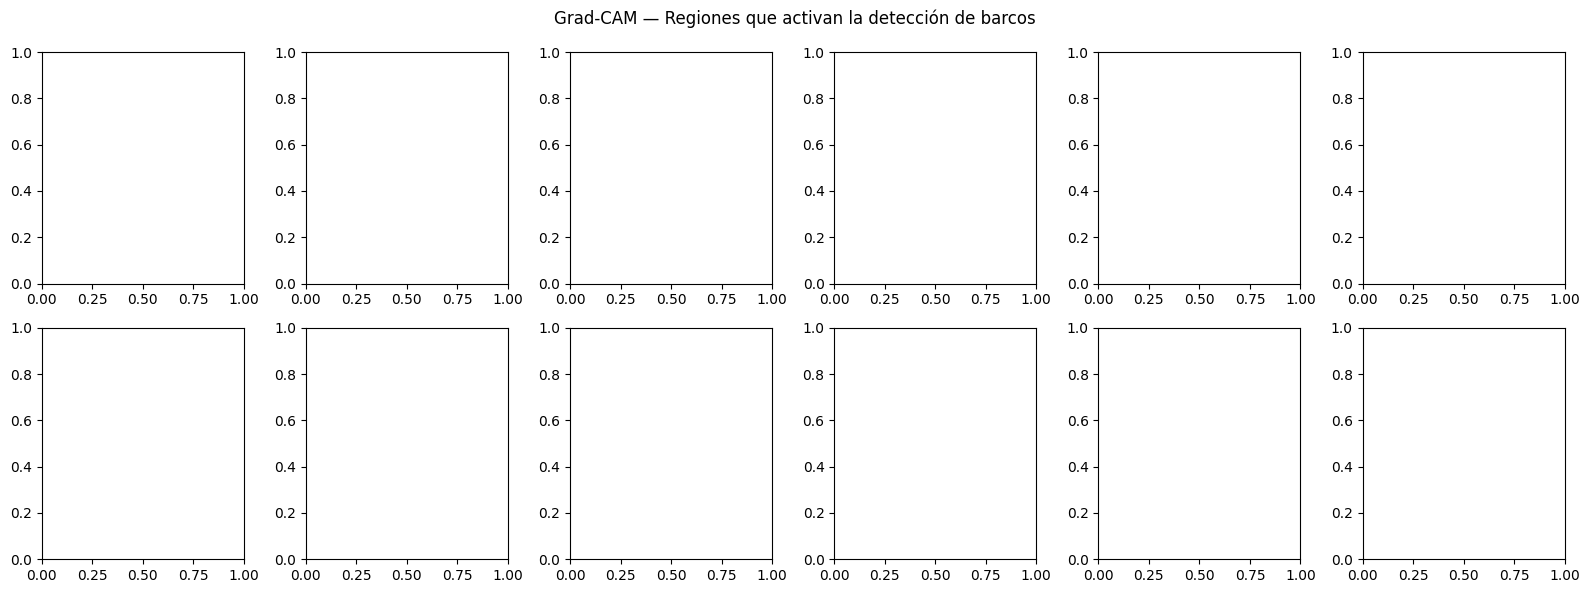

In [ ]:
# CELDA 2 - Loop Grad-CAM sin gradcam_model anidado
ship_indices = np.where(y_test == 1)[0][:6]
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Grad-CAM — Regiones que activan la detección de barcos', fontsize=12)

for i, idx in enumerate(ship_indices):
    img = X_test[idx]
    img_input = tf.convert_to_tensor(
        np.expand_dims(img, 0), dtype=tf.float32
    )

    with tf.GradientTape() as tape:
        tape.watch(img_input)
        # ✅ Pasar por el base_model para obtener conv_output
        conv_output = conv_model(img_input, training=False)
        tape.watch(conv_output)
        # ✅ Predicción con el modelo completo
        preds = mobilenet_model(img_input, training=False)
        score = tf.reduce_sum(preds[:, 0])

    grads = tape.gradient(score, conv_output)

    if grads is None:
        print(f"⚠️ grads es None para idx={idx}")
        continue

    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(
        tf.nn.relu(conv_output[0] * pooled), axis=-1
    ).numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    overlay = overlay_gradcam(img, heatmap)
    prob = float(preds[0, 0])

    axes[0, i].imshow(img)
    axes[0, i].set_title(f'P(barco)={prob:.2f}', fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(overlay)
    axes[1, i].set_title('Grad-CAM', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

Testeo error

In [ ]:
img = X_test[2]
img_input = tf.convert_to_tensor(np.expand_dims(img, 0), dtype=tf.float32)

# persistent=True para calcular múltiples gradientes
with tf.GradientTape(persistent=True) as tape:
    tape.watch(img_input)
    conv_output = conv_model(img_input, training=False)
    tape.watch(conv_output)
    preds = mobilenet_model(img_input, training=False)
    score = tf.reduce_sum(preds[:, 0])

grads = tape.gradient(score, conv_output)
grads2 = tape.gradient(score, img_input)
del tape  # liberar memoria

print("grads (conv_output):", grads)
print("grads2 (img_input):", grads2)
print("score:", score.numpy())
print("preds:", preds.numpy())

grads (conv_output): None
grads2 (img_input): tf.Tensor(
[[[[-8.0864964e-05 -1.9231137e-04 -6.7760382e-05]
   [ 3.4254062e-05 -4.8538241e-06 -1.6535578e-05]
   [ 8.6093796e-06 -1.6507343e-04  4.1922201e-05]
   ...
   [-4.7781778e-05 -2.5583860e-05 -4.1097069e-06]
   [-1.5752739e-04 -1.6940970e-04 -3.0378955e-05]
   [ 7.5435251e-05  2.8072434e-04  6.9705820e-05]]

  [[-1.6194266e-06 -1.1923493e-04 -4.6842622e-05]
   [ 1.3414804e-04  2.1198721e-05  4.1938056e-06]
   [-1.8499662e-04 -4.5015439e-04 -4.2185697e-05]
   ...
   [-1.6464383e-04 -1.9059579e-04 -4.8267386e-05]
   [-4.6437033e-04 -7.2907546e-04 -2.1671884e-04]
   [ 4.0057665e-05  1.6134711e-04  1.7870003e-05]]

  [[-9.8486504e-05 -3.0115864e-04 -1.1270990e-04]
   [-3.4744220e-04 -8.3657447e-04 -2.3082350e-04]
   [-7.6764452e-05 -3.5614305e-04  6.9761096e-05]
   ...
   [ 3.4222213e-04  4.9435312e-04  1.8112297e-04]
   [-1.4761399e-04 -2.3661088e-04 -5.1267467e-05]
   [ 6.0816226e-05  1.1952323e-04  2.8707587e-05]]

  ...

  [[-5.28

Solucion con Saliency Map

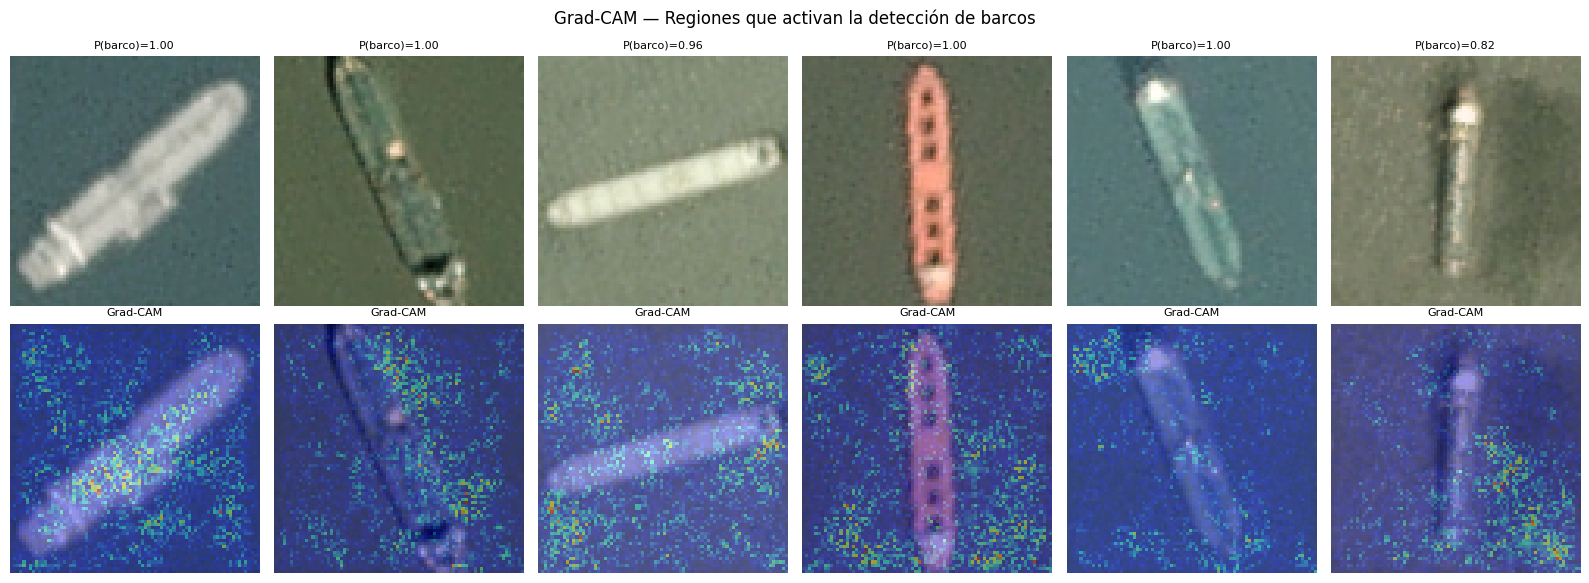

In [ ]:
ship_indices = np.where(y_test == 1)[0][:6]
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Grad-CAM — Regiones que activan la detección de barcos', fontsize=12)

for i, idx in enumerate(ship_indices):
    img = X_test[idx]
    img_input = tf.convert_to_tensor(np.expand_dims(img, 0), dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_input)
        conv_output = conv_model(img_input, training=False)  # (1, H, W, C)
        preds = mobilenet_model(img_input, training=False)
        score = tf.reduce_sum(preds[:, 0])

    # Gradiente respecto al img_input (funciona)
    grads = tape.gradient(score, img_input)  # shape (1, 80, 80, 3)

    # Convertir gradientes del input en heatmap
    # Tomar valor absoluto y colapsar canales RGB
    heatmap = tf.reduce_sum(tf.abs(grads[0]), axis=-1).numpy()  # (80, 80)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    overlay = overlay_gradcam(img, heatmap)
    prob = float(preds[0, 0])

    axes[0, i].imshow(img)
    axes[0, i].set_title(f'P(barco)={prob:.2f}', fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(overlay)
    axes[1, i].set_title('Grad-CAM', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# DIAGNÓSTICO FINAL
mobilenet_base = mobilenet_model.get_layer('mobilenetv2_1.00_224')
print("Input del base_model:", mobilenet_base.input_shape)
print("Output del base_model:", mobilenet_base.output_shape)
print("\nCapas del mobilenet_model (nivel superior):")
for layer in mobilenet_model.layers:
    print(f"  {layer.name}")

Input del base_model: (None, 80, 80, 3)
Output del base_model: (None, 3, 3, 1280)

Capas del mobilenet_model (nivel superior):
  input_layer_5
  mobilenetv2_1.00_224
  global_average_pooling2d_1
  dense_6
  dropout_9
  dense_7


SOLUCIÓN: es construir un grafo unificado pasando el input por el base_model capa por capa para que out_relu quede conectado


In [ ]:
# CELDA 1 - Enfoque con tf.function para capturar tensor intermedio
mobilenet_base = mobilenet_model.get_layer('mobilenetv2_1.00_224')

# Submodelo desde input hasta out_relu (dentro del base_model)
conv_submodel = tf.keras.models.Model(
    inputs=mobilenet_base.input,
    outputs=mobilenet_base.get_layer('out_relu').output
)

# Verificar
print('conv_submodel input:', conv_submodel.input_shape)
print('conv_submodel output:', conv_submodel.output_shape)

conv_submodel input: (None, 80, 80, 3)
conv_submodel output: (None, 3, 3, 1280)


La clave acá es que score se calcula a partir de conv_output directamente — pasando las capas restantes manualmente. Así el tape puede trazar el gradiente desde score hasta conv_output sin depender del grafo simbólico de Keras.

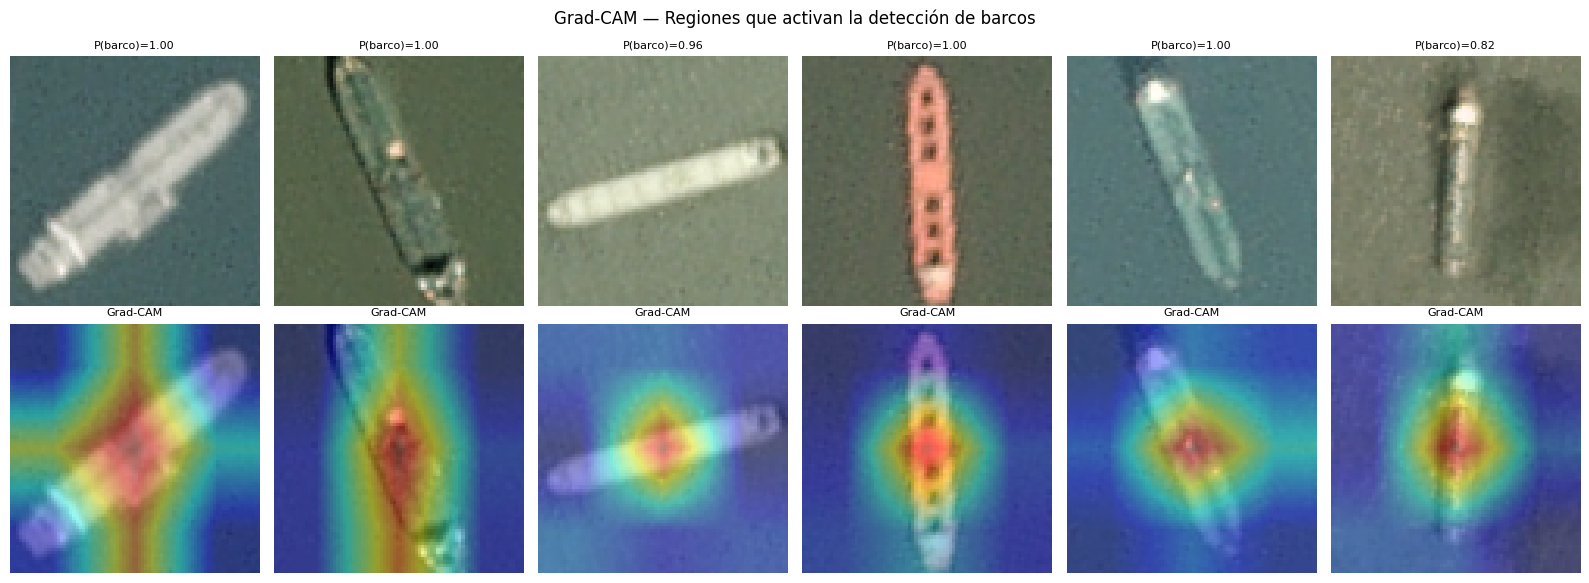

In [ ]:
# CELDA 2 - Grad-CAM con persistent tape
ship_indices = np.where(y_test == 1)[0][:6]
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Grad-CAM — Regiones que activan la detección de barcos', fontsize=12)

for i, idx in enumerate(ship_indices):
    img = X_test[idx]
    img_input = tf.convert_to_tensor(np.expand_dims(img, 0), dtype=tf.float32)

    with tf.GradientTape(persistent=True) as tape:
        #  conv_submodel corre en el mismo eager context
        conv_output = conv_submodel(img_input, training=False)
        tape.watch(conv_output)

        #  Pasar conv_output por las capas restantes manualmente
        x = mobilenet_model.get_layer('global_average_pooling2d_1')(conv_output)
        x = mobilenet_model.get_layer('dense_6')(x)
        x = mobilenet_model.get_layer('dropout_9')(x)
        preds = mobilenet_model.get_layer('dense_7')(x)
        score = tf.reduce_sum(preds[:, 0])

    grads = tape.gradient(score, conv_output)
    del tape

    if grads is None:
        print(f" grads es None para idx={idx}")
        continue

    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(
        tf.nn.relu(conv_output[0] * pooled), axis=-1
    ).numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    overlay = overlay_gradcam(img, heatmap)
    prob = float(preds[0, 0])

    axes[0, i].imshow(img)
    axes[0, i].set_title(f'P(barco)={prob:.2f}', fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(overlay)
    axes[1, i].set_title('Grad-CAM', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 5.3 — Curva ROC y exploración del umbral

<>:31: SyntaxWarning: invalid escape sequence '\ '
<>:31: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_3200/3669056986.py:31: SyntaxWarning: invalid escape sequence '\ '
  print('\ Reflexión sobre el umbral:')


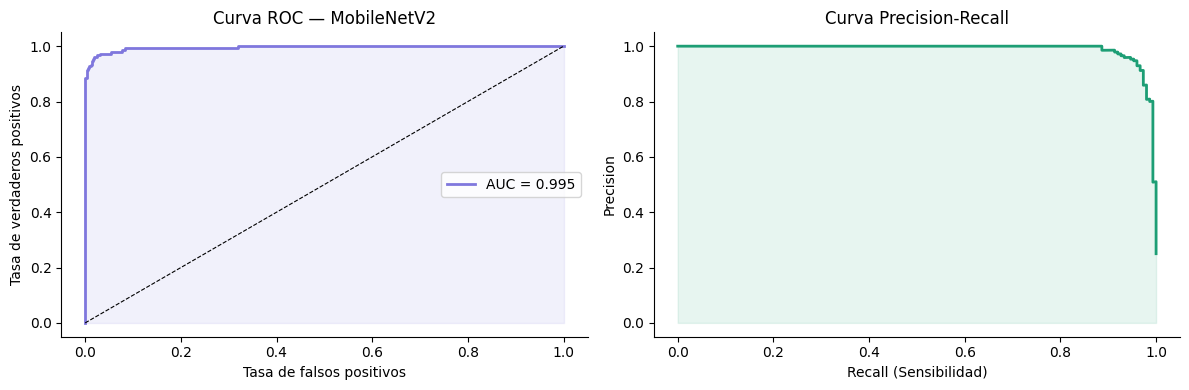

\ Reflexión sobre el umbral:
  • Umbral 0.5:  equilibrio general
  • Umbral bajo: maximizar Recall → detectar TODOS los barcos (pocas FN)
  • Umbral alto: maximizar Precision → solo alertar cuando estamos seguros

En vigilancia marítima, el Recall suele ser más crítico.


In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_mn)
prec, rec, pr_thresholds  = precision_recall_curve(y_test, y_prob_mn)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Curva ROC
axes[0].plot(fpr, tpr, color='#7F77DD', linewidth=2,
             label=f'AUC = {roc_auc_score(y_test, y_prob_mn):.3f}')
axes[0].plot([0,1],[0,1], 'k--', linewidth=0.8)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#7F77DD')
axes[0].set_xlabel('Tasa de falsos positivos')
axes[0].set_ylabel('Tasa de verdaderos positivos')
axes[0].set_title('Curva ROC — MobileNetV2')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Curva Precision-Recall
axes[1].plot(rec, prec, color='#1D9E75', linewidth=2)
axes[1].fill_between(rec, prec, alpha=0.1, color='#1D9E75')
axes[1].set_xlabel('Recall (Sensibilidad)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# ¿Qué umbral elegir?
print('\ Reflexión sobre el umbral:')
print('  • Umbral 0.5:  equilibrio general')
print('  • Umbral bajo: maximizar Recall → detectar TODOS los barcos (pocas FN)')
print('  • Umbral alto: maximizar Precision → solo alertar cuando estamos seguros')
print('\nEn vigilancia marítima, el Recall suele ser más crítico.')

In [ ]:
# Impacto de distintos umbrales en las métricas
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

print(f'\n{"Umbral":>8} {"Precision":>10} {"Recall":>10} {"F1":>8}')
print('-' * 40)
for t in thresholds_to_test:
    y_pred_t = (y_prob_mn >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    marker = ' ← default' if t == 0.5 else ''
    print(f'{t:>8.1f} {p:>10.3f} {r:>10.3f} {f:>8.3f}{marker}')


  Umbral  Precision     Recall       F1
----------------------------------------
     0.3      0.835      0.980    0.902
     0.4      0.855      0.980    0.913
     0.5      0.864      0.973    0.915 ← default
     0.6      0.880      0.973    0.924
     0.7      0.901      0.973    0.936


---
# 6 — Evaluación final, exportación y cierre
> **Objetivos:** reporte de métricas completo, exportar el modelo en SavedModel y TFLite, discutir próximos pasos y datasets avanzados.

## 6.1 — Reporte final completo

In [ ]:
from sklearn.metrics import cohen_kappa_score

print('\n' + '█'*60)
print('  REPORTE FINAL — MobileNetV2 Fine-tuned')
print('█'*60)

print('\n── Classification Report ──────────────────────────')
print(classification_report(y_test, y_pred_mn,
                             target_names=['No barco', 'Barco']))

kappa = cohen_kappa_score(y_test, y_pred_mn)
auc   = roc_auc_score(y_test, y_prob_mn)

print(f'AUC-ROC:      {auc:.4f}')
print(f"Cohen's κ:    {kappa:.4f}")

print('\nInterpretación de Cohen κ:')
print('  0.00–0.20 = leve  | 0.21–0.40 = regular | 0.41–0.60 = moderado')
print('  0.61–0.80 = bueno | 0.81–1.00 = casi perfecto')


████████████████████████████████████████████████████████████
  REPORTE FINAL — MobileNetV2 Fine-tuned
████████████████████████████████████████████████████████████

── Classification Report ──────────────────────────
              precision    recall  f1-score   support

    No barco       0.99      0.95      0.97       450
       Barco       0.86      0.97      0.92       150

    accuracy                           0.95       600
   macro avg       0.93      0.96      0.94       600
weighted avg       0.96      0.95      0.96       600

AUC-ROC:      0.9954
Cohen's κ:    0.8849

Interpretación de Cohen κ:
  0.00–0.20 = leve  | 0.21–0.40 = regular | 0.41–0.60 = moderado
  0.61–0.80 = bueno | 0.81–1.00 = casi perfecto


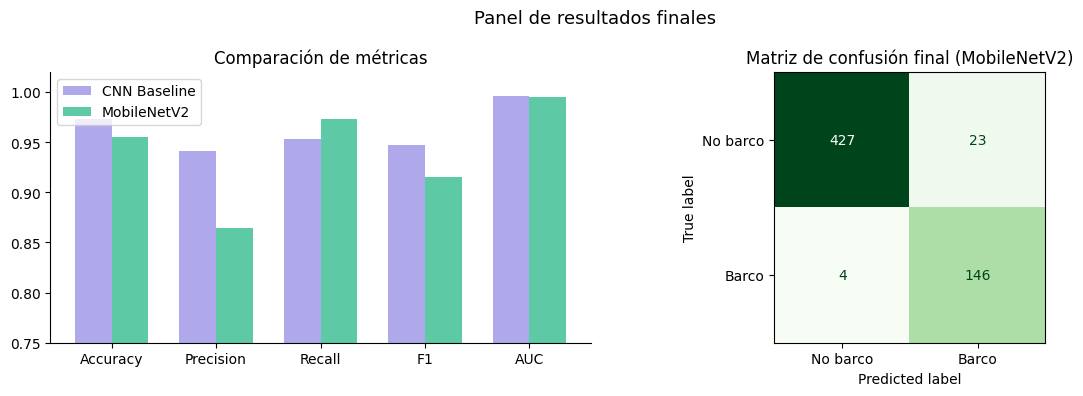

In [ ]:
# Panel resumen visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Panel de resultados finales', fontsize=13)

# Barra de métricas
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
cnn_vals = [
    (y_pred_cnn == y_test).mean(),
    precision_score(y_test, y_pred_cnn),
    recall_score(y_test, y_pred_cnn),
    f1_score(y_test, y_pred_cnn),
    roc_auc_score(y_test, y_prob_cnn)
]
mn_vals = [
    (y_pred_mn == y_test).mean(),
    precision_score(y_test, y_pred_mn),
    recall_score(y_test, y_pred_mn),
    f1_score(y_test, y_pred_mn),
    auc
]

x = np.arange(len(metric_names))
w = 0.35
axes[0].bar(x - w/2, cnn_vals, w, label='CNN Baseline', color='#AFA9EC')
axes[0].bar(x + w/2, mn_vals,  w, label='MobileNetV2',  color='#5DCAA5')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names)
axes[0].set_ylim(0.75, 1.02)
axes[0].set_title('Comparación de métricas')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Matriz de confusión final
cm = confusion_matrix(y_test, y_pred_mn)
disp = ConfusionMatrixDisplay(cm, display_labels=['No barco', 'Barco'])
disp.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Matriz de confusión final (MobileNetV2)')

plt.tight_layout()
plt.show()

## 6.2 — Exportación del modelo

In [ ]:
import shutil

# ── Formato SavedModel (TensorFlow estándar) ──────────────
SAVED_MODEL_PATH = 'modelo_barcos_savedmodel'
mobilenet_model.save(SAVED_MODEL_PATH)
print(f'Modelo guardado en: {SAVED_MODEL_PATH}/')

# ── Formato Keras nativo (.keras) ────────────────────────
mobilenet_model.save('modelo_barcos.keras')
print('Modelo guardado como: modelo_barcos.keras')

In [ ]:
# ── Conversión a TFLite (para dispositivos con recursos limitados) ──
converter = tf.lite.TFLiteConverter.from_keras_model(mobilenet_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Cuantización float16
tflite_model = converter.convert()

with open('modelo_barcos.tflite', 'wb') as f:
    f.write(tflite_model)

size_saved = sum(
    os.path.getsize(os.path.join(root, file))
    for root, _, files in os.walk(SAVED_MODEL_PATH)
    for file in files
) / 1e6

size_tflite = os.path.getsize('modelo_barcos.tflite') / 1e6

print(f'\nTamaño SavedModel: {size_saved:.1f} MB')
print(f'Tamaño TFLite:     {size_tflite:.1f} MB  (comprimido para deploy)')

In [ ]:
# Verificar que el modelo TFLite funciona correctamente
interpreter = tf.lite.Interpreter(model_path='modelo_barcos.tflite')
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Inferencia de prueba con una sola imagen
test_img = X_test[0:1].astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], test_img)
interpreter.invoke()
tflite_pred = interpreter.get_tensor(output_details[0]['index'])

print(f' Inferencia TFLite exitosa')
print(f'   Predicción: {tflite_pred[0][0]:.4f} — Clase real: {y_test[0]}')

In [ ]:
# Descargar los modelos exportados desde Colab
from google.colab import files

print(' Descargando modelos exportados...')
files.download('modelo_barcos.keras')
files.download('modelo_barcos.tflite')

## 6.3 — Función de inferencia para nuevas imágenes

In [ ]:
def predict_image(image_path_or_array, model, threshold=0.5):
    """
    Predice si una imagen satelital contiene un barco.

    Args:
        image_path_or_array: ruta a imagen PNG/JPG o array numpy (80,80,3)
        model: modelo Keras entrenado
        threshold: umbral de decisión (default 0.5)

    Returns:
        dict con 'clase', 'probabilidad' y 'confianza'
    """
    if isinstance(image_path_or_array, str):
        img = np.array(Image.open(image_path_or_array).resize((80, 80))) / 255.0
    else:
        img = image_path_or_array

    img_batch = np.expand_dims(img, axis=0)
    prob = float(model.predict(img_batch, verbose=0)[0, 0])

    return {
        'clase':        'BARCO' if prob >= threshold else 'NO BARCO',
        'probabilidad': round(prob, 4),
        'confianza':    f'{max(prob, 1-prob)*100:.1f}%'
    }

# Probar con algunas imágenes del test set
print('Ejemplos de predicción con la función final:\n')
for i in [0, 1, 2]:
    result = predict_image(X_test[i], mobilenet_model)
    print(f'  Imagen {i}: {result}  (verdadero: {"BARCO" if y_test[i] else "NO BARCO"})')

## 6.4 — Próximos pasos y recursos

### ¿Qué podés explorar después?

| Nivel | Tópico | Dataset / Recurso |
|-------|--------|-------------------|
| ⭐⭐ | Detección con bounding boxes | Airbus Ship Detection (Kaggle) |
| ⭐⭐ | Segmentación semántica | Airbus Ship Detection + U-Net |
| ⭐⭐⭐ | Detección en tiempo real | YOLOv8 + imágenes propias |
| ⭐⭐⭐ | Imágenes SAR (radar) | Sentinel-1 (ESA) |
| ⭐⭐⭐ | Multitemporal (series) | Planet Labs / Copernicus |

### Papers y recursos clave

- **Selvaraju et al. (2017)** — Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization
- **Howard et al. (2017)** — MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications
- **Kaggle** — Airbus Ship Detection Challenge (máscaras RLE, F2-score)
- **ESA Open Access Hub** — Sentinel-1 & Sentinel-2 para uso académico gratuito
- **TF Lite Guide** — https://www.tensorflow.org/lite/guide

### 🏆 Competencia para practicar
- [Airbus Ship Detection](https://www.kaggle.com/c/airbus-ship-detection) — clasificación + segmentación
- [Planet: Understanding the Amazon from Space](https://www.kaggle.com/c/planet-understanding-the-amazon-from-space)

In [ ]:
print('🎓 ¡Felicitaciones por completar el proyecto!')
print()
print('Resumen de lo aprendido:')
print('  Configuración de entorno en Google Colab con GPU')
print('  Descarga y exploración de datasets desde Kaggle')
print('  Preprocesamiento y data augmentation')
print('  Diseño de CNN desde cero')
print('  Transfer Learning y fine-tuning con MobileNetV2')
print('  Interpretabilidad con Grad-CAM')
print('  Análisis de errores y selección de umbral')
print('  Exportación en SavedModel y TFLite')